# Task 1

In [2]:
# These code snippets that parse parts of run_provided.m
# have kindly been shared by Markus Bjørklund
#
# Please note that you'll need to do some work to put these snippets 
# into work in the appropriate order, for example, in a Jupyter notebook
# or by calling things in the right order from a main()


#For parsing and general analysis
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

#For datetime objects
from matplotlib import dates
from datetime import datetime, timedelta
import dateutil.parser

#For map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geopy.distance import great_circle

# Set path for data
path = os.path.abspath('') + '/' #Working directory path (Where program is run from)
fn_list = os.listdir(path + '/data') #List of all file names

def parse(num_files=None):
    #Read files and store contents. Accepts user input for number of files to read.
    if num_files:
        N_files = num_files
    else:
        N_files = len(fn_list)

    # Initialize
    lats = np.zeros(N_files)
    lons = np.zeros(N_files)
    dt = np.zeros(N_files)

    N_samples = 720000 #Size of the datasets in the files. Hard coded unless you want dynamic allocation (lists, slower)
    data_collection = np.zeros((N_files,N_samples)) # all station data
    times_collection = np.zeros((N_files,N_samples), dtype=datetime) # all correponding time vectors


    #Loop over files
    for ii in range(N_files):
        if (ii%50) == 0:
            print('Loading station ' , ii, ' out of ' , N_files-1)

        this_fn = h5py.File(path + 'data/' + fn_list[ii], 'r') # The file path we will read

        # Read the latitude and longitude attributes for the station and put into vectors
        lats[ii] = this_fn.attrs['latitude']
        lons[ii] = this_fn.attrs['longitude']

        #Read tree structure and load dataset into aggregate array
        level1 = list(this_fn.keys()) # /waveforms
        level2 = list(this_fn[level1[0]].keys()) # /waveforms/dataset_name
        dataset = this_fn['/' + level1[0] + '/' + level2[0]] #Reading dataset in subgroup
        data = dataset[:] #Extract numpy array from dataset object

        #If missing data, pad with zeros
        if len(data) < N_samples:
            #data = np.pad(data, (0, N_samples-len(data)), 'constant', constant_values=np.nan)
            data = np.pad(data, (0, N_samples-len(data)), 'constant', constant_values=0)

        data_collection[ii,:] = data #Loading numpy array into aggregate data array

        # Figure out the start time and generate a time vector
        start_time_str = dataset.attrs['starttime']
        start_time = dateutil.parser.isoparse(start_time_str) #Time attribute on ISO-format

        dt[ii] = dataset.attrs['delta']
        deltas = np.linspace(0, dt[ii]*(N_samples-1), N_samples) #A duration which can be added to a datetime object
        times = start_time + deltas*timedelta(seconds = 1)
        times_collection[ii,:] = times #Loading times into aggregate array

    print('done')
    return data_collection, times_collection, lats, lons, dt

def plot_map(lats, lons, tonga_latlon):
    northward_offset = 90 #As in sample program
    central_lat = tonga_latlon[0] + northward_offset
    central_lon = tonga_latlon[1]

    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(1, 1, 1, 
    projection=ccrs.AzimuthalEquidistant(central_latitude = central_lat, central_longitude=central_lon))

    #Stock background (Natural Earth)
    ax.stock_img()

    #Make the map global rather than have it zoom in to the extents of any plotted data
    ax.set_global()
    
    #Make gridlines
    ax.gridlines(crs=ccrs.PlateCarree())

    #Plot stations and Hunga Tonga
    ax.scatter(tonga_latlon[1], tonga_latlon[0], marker = 'x', linewidth = 2, 
    color='red', transform=ccrs.PlateCarree()) #Transform is PlateCarree regardless of projection

    ax.scatter(lons, lats, marker = '^', linewidth = 0.5, facecolor='none', 
    edgecolor='magenta', transform=ccrs.PlateCarree()) #Transform is PlateCarree regardless of projection

    plt.show()


def circle_distance(n_files, lats, lons, tonga_latlon):
    #Calculate great circle distance. Using geopy.great_circle
    dists = []
    for i in range(n_files):
        dists.append(great_circle((tonga_latlon[0], tonga_latlon[1]) , (lats[i], lons[i])).m)
        
    dists = np.array(dists)
    dists_km = dists/1000
    
    print('Smallest great cricle distance is {:.2f}km. Largest great circle distance is {:.2f}km'.format(
        np.min(dists_km), np.max(dists_km)))
    
    plt.style.use('seaborn-v0_8-whitegrid')
    n_vec = np.linspace(0,n_files-1,n_files)
    fig = plt.figure(figsize=(15,10))
    ax = fig.add_subplot(111)
    ax.scatter(n_vec, np.sort(dists_km), s=0.5)
    ax.set_xlabel('Station number', fontsize=28)
    ax.set_ylabel('Distance, [km]', fontsize=28)
    ax.set_title('Great circle distances between Hunga Tonga and stations', fontsize=28)
    plt.show()

    return dists_km


# READ DATA
data_collection, times_collection, lats, lons, dt = parse()
n_files = len(lats)

# Hunga Tonga location
tonga_latlon = [-20.550, -175.385] # latitude and longitude

# Map
plot_map(lats, lons, tonga_latlon)

dists_km = circle_distance(n_files, lats, lons, tonga_latlon)

Loading station  0  out of  200


KeyboardInterrupt: 

# Task 2
## a)

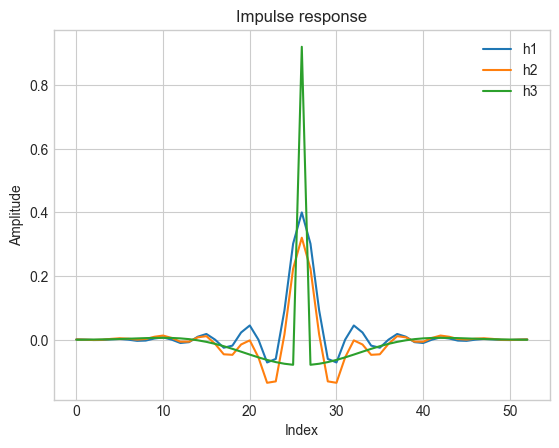

In [12]:
# Loop that turns impulse textfile into lists in matlab format to Python lists
with open("impulse_response.txt") as file:
    text = file.read()

lists = []

for section in text.split(";"):
    if "[" not in section:
        continue

    numbers = section.split("[")[1].split("]")[0]
    number_list = [float(n) for n in numbers.split()]
    lists.append(number_list)

h1, h2, h3 = lists

x_verdier = np.arange(0,len(h1))

plt.plot(x_verdier, h1, label = "h1")
plt.plot(x_verdier, h2, label = "h2")
plt.plot(x_verdier, h3, label = "h3")
plt.xlabel("Index")
plt.ylabel("Amplitude")
plt.title("Impulse response")
plt.legend()
plt.show()

## b)

In [19]:
def convolve(input_signal, impulse_response, ylen_choice):
    x = np.array(input_signal)
    h = np.array(impulse_response)

    if ylen_choice == 0:
        y = np.zeros(len(x))

        for n in range(len(x)):
            for k in range(len(x)):
                if 0 <= n-k < len(h):
                    y[n] += x[k] * h[n-k]

        return y

    else:
        y = np.zeros((len(x) + len(h)) - 1)

        for n in range(len(y)):
                    for k in range(len(x)):
                        if 0 <= n-k < len(h):
                            y[n] += x[k] * h[n-k]

        return y


# Testing if the function works
x = np.array([1, 2, 3])
h = np.array([1, 2])

print(convolve(x, h, 1))
print(np.convolve(x, h, mode="full"))


[1. 4. 7. 6.]
[1 4 7 6]


## c)

In [31]:
def DTFT(input_signal, N, fs):
    h = np.array(input_signal)
    y = np.zeros(N, dtype = complex)
    length = len(h)
    freq = np.array([(k*fs)/N for k in range(0, N)])
    omega = 2 * np.pi * freq / fs

    for k in range(0, len(y)):
        for n in range(0, length):
            y[k] += h[n] * np.exp(-1j * omega[k] * n)

    return y, freq

# Test of DTFT-function
h = np.array([1, 2, 1])
H, freq = DTFT(h, 4, 1000)

print("Frequency (Hz):", freq)
print("DTFT:", np.round(H, 4))

Frequency (Hz): [  0. 250. 500. 750.]
DTFT: [ 4.+0.j  0.-2.j  0.+0.j -0.+2.j]


## d)

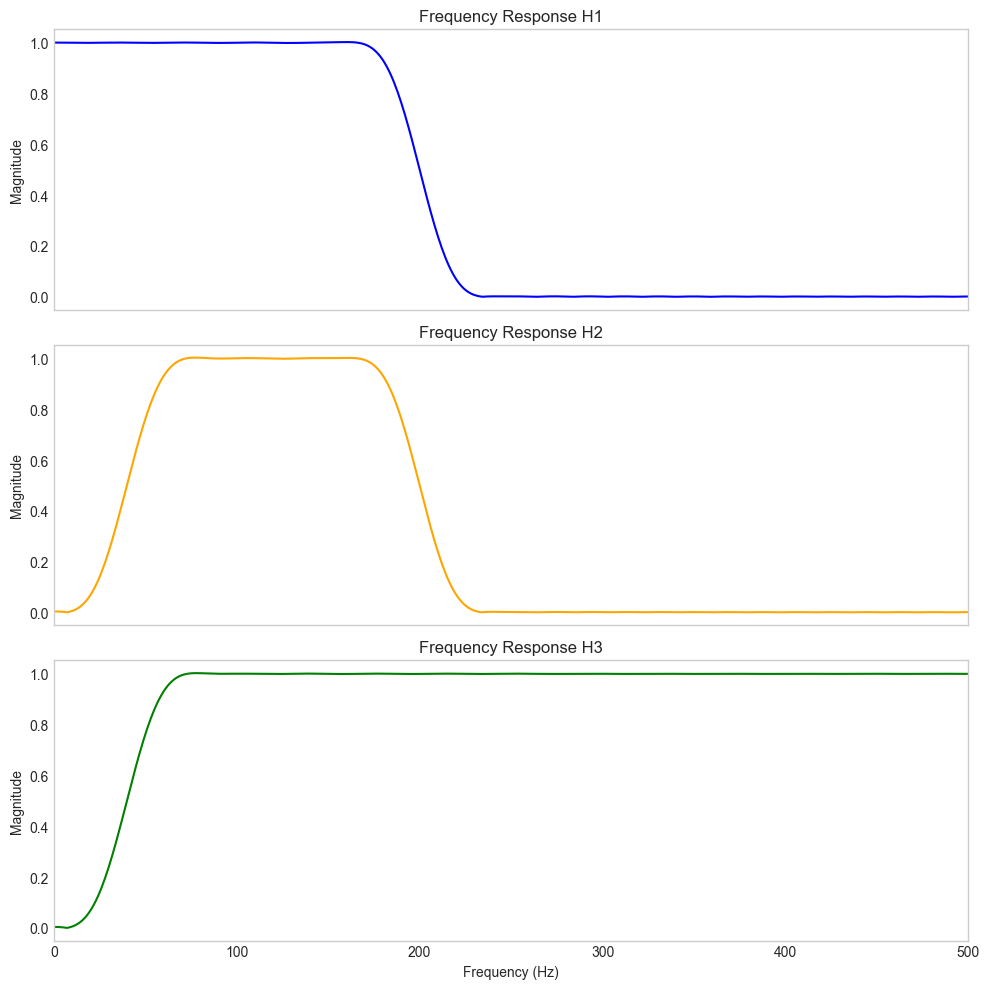

In [41]:
N = 1000
fs = 1000

# Calculate DTFT
H1, freq = DTFT(h1, N, fs)
H2, freq2 = DTFT(h2, N, fs)
H3, freq3= DTFT(h3, N, fs)

# Plots
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# H1
axs[0].plot(freq, np.abs(H1), color="blue")
axs[0].set_title("Frequency Response H1")
axs[0].set_ylabel("Magnitude")
axs[0].grid()

# H2
axs[1].plot(freq, np.abs(H2), color="orange")
axs[1].set_title("Frequency Response H2")
axs[1].set_ylabel("Magnitude")
axs[1].grid()

# H3
axs[2].plot(freq, np.abs(H3), color="green")
axs[2].set_title("Frequency Response H3")
axs[2].set_ylabel("Magnitude")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_xlim(0, fs / 2)
axs[2].grid()

plt.tight_layout()
plt.show()

### e) Filter classification

Based on the frequency responses:

**h1[n] is a low-pass filter**, as it allows low frequencies to pass while attenuating higher frequencies.

**h2[n] is a band-pass filter**, as it attenuates both low and high frequencies while allowing an intermediate frequency range to pass.

**h3[n] is a high-pass filter**, as it attenuates low frequencies while allowing higher frequencies to pass.


## f)

In [46]:
# Store the filtered signals
filtered_h1 = []
filtered_h2 = []
filtered_h3 = []

for x in data_collection:
    filtered_h1.append(np.convolve(x, h1, mode="same"))
    filtered_h2.append(np.convolve(x, h2, mode="same"))
    filtered_h3.append(np.convolve(x, h3, mode="same"))

# Convert to NumPy arrays
filtered_h1 = np.array(filtered_h1)
filtered_h2 = np.array(filtered_h2)
filtered_h3 = np.array(filtered_h3)

print("Original data:", data_collection.shape)
print("Low-pass:", filtered_h1.shape)
print("Band-pass:", filtered_h2.shape)
print("High-pass:", filtered_h3.shape)

Original data: (201, 720000)
Low-pass: (201, 720000)
Band-pass: (201, 720000)
High-pass: (201, 720000)


## g)

In [1]:
plt.figure(figsize=(12, 8))
# Common reference time
start = times_collection[0, 0]
for i in range(len(dists_km)):

    # Band-pass filtered signal
    signal = filtered_h2[i]

    # Time in hours relative to the common reference
    offset = (times_collection[i, 0] - start).total_seconds() / 3600
    time = offset + np.arange(len(signal)) * dt[i] / 3600

    # Normalize the signal
    signal = signal / (np.max(np.abs(signal)) + 1e-12)

    # Plot every 20th sample
    plt.plot(time,
             dists_km[i] + signal * 100,
             color="black", linewidth=0.4)

plt.xlabel("Time (hours)")
plt.ylabel("Distance from Hunga Tonga (km)")
plt.title("Hunga Tonga - Band-pass Filtered Record Section")
plt.ylim(0, 21000)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined